# Architecture 2 — Bidirectional CNN-LSTM Hybrid (MIMO)

## Executive Summary
**Objective:** Train a CNN-LSTM model that takes a 48-hour lookback window as input and simultaneously predicts all 24 future horizons (MIMO strategy). Compare against Architecture 1.

**Architecture:**
```
Input (batch, 48, n_features)
 → Conv1D(64) + BN + Conv1D(128) + BN + MaxPool + Dropout(0.2)
 → BiLSTM(128) + Dropout(0.3) → BiLSTM(64)
 → Dense(64, ReLU) → Dense(24)  [all horizons at once]
```

**Key design choices:**
- MIMO (single model, 24 outputs) — more stable than 24 separate DL models
- Huber loss (delta=1.0) — robust to PM2.5 outlier spikes
- log1p target transform + StandardScaler on inputs
- EarlyStopping patience=15

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_PATH, TARGET, HORIZONS, SEQ_LEN_LSTM,
    MODEL_DIR, FIGURES_DIR, RESULTS_DIR
)
from src.data_loader import load_data, train_test_split
from src.feature_engineering import build_sequence_dataset
from src.models.hybrid_lstm import train_cnn_lstm, predict_cnn_lstm, load_cnn_lstm
from src.evaluation import compute_metrics, plot_horizon_metrics, plot_actual_vs_predicted
from src.utils import ensure_dirs, set_seed

set_seed(42)
ensure_dirs(MODEL_DIR, FIGURES_DIR, RESULTS_DIR)
sns.set_theme(style='whitegrid', palette='tab10')
print('Setup complete')

Setup complete


## 1. Load Data and Build Sequence Datasets

In [2]:
df = load_data(DATA_PATH)
train_df, test_df = train_test_split(df)

# Build sequences — scaler fitted on train only
X_train_seq, y_train_seq, feature_names, scaler_X = build_sequence_dataset(
    train_df, seq_len=SEQ_LEN_LSTM, horizons=HORIZONS, fit_scaler=True
)

# Apply same scaler to test (no fit)
X_test_seq, y_test_seq, _, _ = build_sequence_dataset(
    test_df, seq_len=SEQ_LEN_LSTM, horizons=HORIZONS,
    scaler_X=scaler_X, fit_scaler=False
)

print(f'Train sequences: X={X_train_seq.shape}, y={y_train_seq.shape}')
print(f'Test  sequences: X={X_test_seq.shape}, y={y_test_seq.shape}')
print(f'Features ({len(feature_names)}): {feature_names[:5]}...')

15:41:28 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
15:41:28 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
15:41:28 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00
15:41:28 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)
15:41:28 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)
15:41:28 | src.feature_engineering | INFO | build_sequence_dataset | seq_len=48 | weather_mode=current
15:41:28 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
15:41:28 | src.feature_engineering | INFO | Retaining 10 HY

Train sequences: X=(37879, 48, 45), y=(37879, 24)
Test  sequences: X=(7709, 48, 45), y=(7709, 24)
Features (45): ['TEMP', 'WIND_SPEED', 'PRESS_SEA', 'HUMIDITY', 'DEW_POINT']...


## 2. Validation Split
Use the last 10% of training sequences as validation (chronological, no shuffle).

In [3]:
val_size = int(0.1 * len(X_train_seq))
X_tr = X_train_seq[:-val_size]
y_tr = y_train_seq[:-val_size]
X_val = X_train_seq[-val_size:]
y_val = y_train_seq[-val_size:]

print(f'Train: {X_tr.shape} | Val: {X_val.shape}')

Train: (34092, 48, 45) | Val: (3787, 48, 45)


## 3. Train CNN-LSTM
Training runs for up to 100 epochs with early stopping (patience=15).

In [4]:
model_path = MODEL_DIR / 'cnn_lstm_model.pt'

cnn_lstm_model, history = train_cnn_lstm(
    X_tr, y_tr, X_val, y_val,
    epochs=100, batch_size=64, patience=15, lr=1e-3,
    save_path=model_path
)
print('Training complete.')

15:41:28 | src.models.hybrid_lstm | INFO | Training CNN-LSTM on cpu
15:41:32 | src.models.hybrid_lstm | INFO | CNN-LSTM | seq_len=48  n_features=45  n_horizons=24  device=cpu
15:41:32 | src.models.hybrid_lstm | INFO | Params: epochs=100  batch=64  patience=15  lr=0.00100
15:41:32 | src.models.hybrid_lstm | INFO | Training samples=34092  val samples=3787
15:41:32 | src.models.hybrid_lstm | INFO | -----------------------------------------------------------------
15:42:26 | src.models.hybrid_lstm | INFO | Epoch   1/100  train=0.18497  val=0.07342  best=0.07342  lr=1.00e-03 *
15:43:15 | src.models.hybrid_lstm | INFO | Epoch   2/100  train=0.08550  val=0.06880  best=0.06880  lr=1.00e-03 *
15:44:05 | src.models.hybrid_lstm | INFO | Epoch   3/100  train=0.07057  val=0.08020  best=0.06880  lr=1.00e-03  (no improve 1/15)
15:44:56 | src.models.hybrid_lstm | INFO | Epoch   4/100  train=0.05806  val=0.08226  best=0.06880  lr=1.00e-03  (no improve 2/15)
15:45:51 | src.models.hybrid_lstm | INFO | Ep

Training complete.


## 4. Training Loss Curves

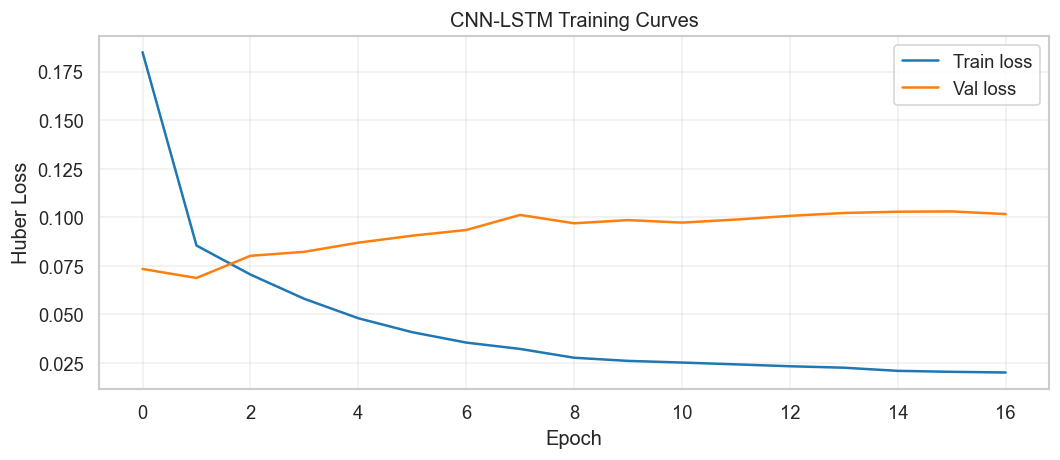

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history['train_loss'], label='Train loss')
ax.plot(history['val_loss'], label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.set_title('CNN-LSTM Training Curves')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'arch2_loss_curves.png', bbox_inches='tight')
plt.show()

## 5. Evaluate on Test Set

In [6]:
# Predictions in µg/m³ (expm1 applied inside predict_cnn_lstm)
cnn_preds = predict_cnn_lstm(cnn_lstm_model, X_test_seq)

# True values also need expm1 (y_test_seq is log1p-transformed)
y_test_true = np.expm1(y_test_seq)

results_cnn = {}
for h_idx, h in enumerate(HORIZONS):
    results_cnn[h] = compute_metrics(y_test_true[:, h_idx], cnn_preds[:, h_idx])

print('CNN-LSTM Results:')
for h in [1, 6, 12, 24]:
    m = results_cnn[h]
    print(f'  h={h:2d}: MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.3f}')

CNN-LSTM Results:
  h= 1: MAE=2.764  RMSE=3.831  R²=0.792
  h= 6: MAE=3.615  RMSE=5.163  R²=0.619
  h=12: MAE=4.817  RMSE=6.895  R²=0.320
  h=24: MAE=4.859  RMSE=6.780  R²=0.349


## 6. Horizon Comparison: Architecture 1 vs Architecture 2

15:54:00 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\arch1_vs_arch2_mae.png


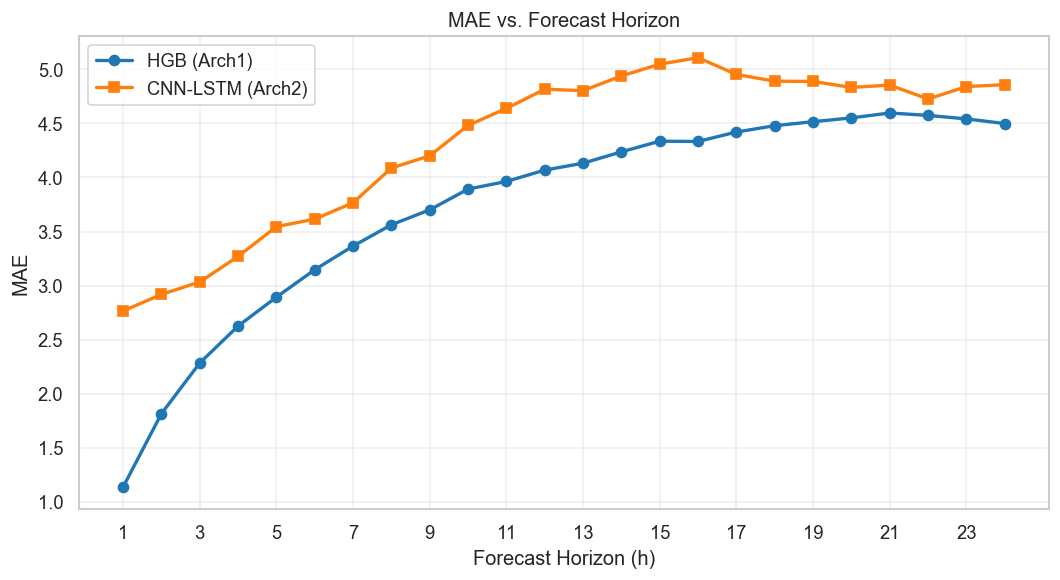

In [7]:
# Load Architecture 1 results if saved
arch1_path = RESULTS_DIR / 'arch1_metrics.csv'
if arch1_path.exists():
    arch1_df = pd.read_csv(arch1_path)
    results_hgb = {}
    for _, row in arch1_df[arch1_df['Model'] == 'Arch1_HGB'].iterrows():
        results_hgb[int(row['Horizon'])] = {
            'MAE': row['MAE'], 'RMSE': row['RMSE'], 'R2': row['R2'],
            'MBE': row['MBE'], 'IA': row['IA']
        }
    combined_results = {'HGB (Arch1)': results_hgb, 'CNN-LSTM (Arch2)': results_cnn}
else:
    combined_results = {'CNN-LSTM (Arch2)': results_cnn}
    print('Arch1 results not found — run notebook 01 first for full comparison')

fig = plot_horizon_metrics(combined_results, metric='MAE',
                            save_path=FIGURES_DIR / 'arch1_vs_arch2_mae.png')
plt.show()

## 7. Scatter Plots at Key Horizons

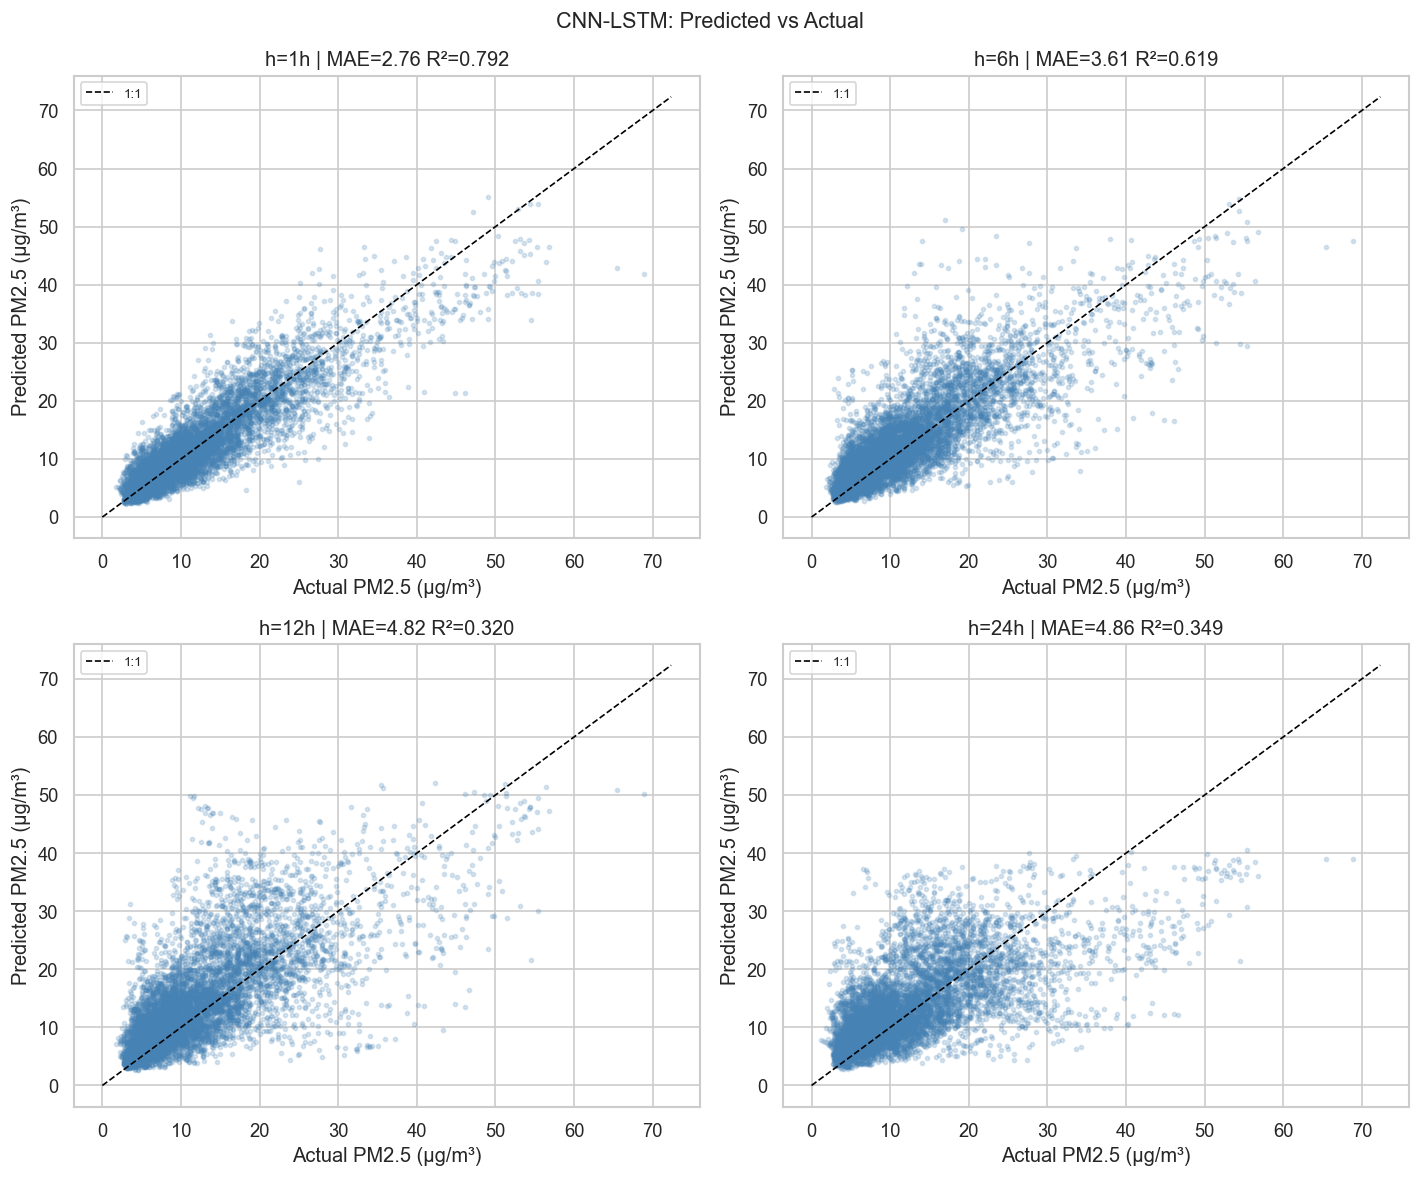

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
key_horizons = [1, 6, 12, 24]

for ax, h in zip(axes.flat, key_horizons):
    h_idx = h - 1
    y_t = y_test_true[:, h_idx]
    y_p = cnn_preds[:, h_idx]
    m = results_cnn[h]
    ax.scatter(y_t, y_p, alpha=0.2, s=6, color='steelblue')
    lim = max(y_t.max(), y_p.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1')
    ax.set_xlabel('Actual PM2.5 (µg/m³)')
    ax.set_ylabel('Predicted PM2.5 (µg/m³)')
    ax.set_title(f'h={h}h | MAE={m["MAE"]:.2f} R²={m["R2"]:.3f}')
    ax.legend(fontsize=8)

fig.suptitle('CNN-LSTM: Predicted vs Actual', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'arch2_scatter_plots.png', bbox_inches='tight')
plt.show()

## 8. Save Results

In [9]:
rows = []
for h, metrics in results_cnn.items():
    rows.append({'Model': 'Arch2_CNN_LSTM', 'Horizon': h, **metrics})

arch2_df = pd.DataFrame(rows)
arch2_df.to_csv(RESULTS_DIR / 'arch2_metrics.csv', index=False)
print('Saved arch2_metrics.csv')

Saved arch2_metrics.csv
